In [1]:
# how to uncover truths that don't matter - first section.

# basic script to load in two datasets, merging them together, and ensure dtypes in dataframe

# loading libraries already for later use
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd
import geopandas as gpd

import geodatasets
from shapely.geometry import Point, box

# loading dataframes
fdf = pd.read_csv("data/flights_sample_3m.csv")
ldf = pd.read_csv("data/airports.csv")

# Define time columns
time_columns = ["ARR_TIME", "DEP_TIME", "WHEELS_OFF", "WHEELS_ON", "CRS_ARR_TIME", "CRS_DEP_TIME"]

# defining a helper function
def convert_time(df, time_columns):
    """ Convert integer time columns to HH:MM format """
    for col in time_columns:
        # Handle missing values and convert times
        df[col] = df[col].fillna(0).astype(int).apply(lambda x: f"{x//100:02d}:{x%100:02d}")
        # Adjust for hours == 24
        df[col] = df[col].replace("24:00", "00:00")
    return df

# convert to datetime
fdf["FL_DATE"] = pd.to_datetime(fdf["FL_DATE"])

# Apply the time conversion
fdf = convert_time(fdf, time_columns)

# Combine dates and times into datetime
fdf["arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["ARR_TIME"])
fdf["dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["DEP_TIME"])

fdf["crs_arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_ARR_TIME"])
fdf["crs_dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_DEP_TIME"])

fdf["woff_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_OFF"])
fdf["won_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_ON"])

# Drop original time columns
fdf = fdf.drop(time_columns, axis=1)

# setting up boolean columns
boolean_columns = ["CANCELLED", "DIVERTED"]
fdf[boolean_columns] = fdf[boolean_columns].astype("bool")

# setting up categorical columns
categorical = ["ORIGIN", "DEST", "ORIGIN_CITY", "DEST_CITY", "AIRLINE", "AIRLINE_DOT", "AIRLINE_CODE", "CANCELLATION_CODE"] 
fdf[categorical] = fdf[categorical].astype("category")

# setting up merge
# Check unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  # "IATA" is the column with the airport acronyms

# Find missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# Drop rows where "ORIGIN" or "DEST" are in missing_airports
fdf_cleaned = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# Merge fdf with ldf to add geographical data for ORIGIN and DEST
fdf_merged = pd.merge(fdf_cleaned, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")
fdf_merged = pd.merge(fdf_merged, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# Drop original origin and destination columns
fdf_merged = fdf_merged.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf_merged[["IATA_ORIGIN", "IATA_DEST"]] = fdf_merged[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

# checking dtypes of columns to doublecheck if everything worked as intended
print(fdf_merged.dtypes)

FL_DATE                    datetime64[ns]
AIRLINE                          category
AIRLINE_DOT                      category
AIRLINE_CODE                     category
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN_CITY                      category
DEST_CITY                        category
DEP_DELAY                         float64
TAXI_OUT                          float64
TAXI_IN                           float64
ARR_DELAY                         float64
CANCELLED                            bool
CANCELLATION_CODE                category
DIVERTED                             bool
CRS_ELAPSED_TIME                  float64
ELAPSED_TIME                      float64
AIR_TIME                          float64
DISTANCE                          float64
DELAY_DUE_CARRIER                 float64
DELAY_DUE_WEATHER                 float64
DELAY_DUE_NAS                     float64
DELAY_DUE_SECURITY                float64
DELAY_DUE_LATE_AIRCRAFT           

In [2]:
# I have the data, so let’s figure out what the question is later!

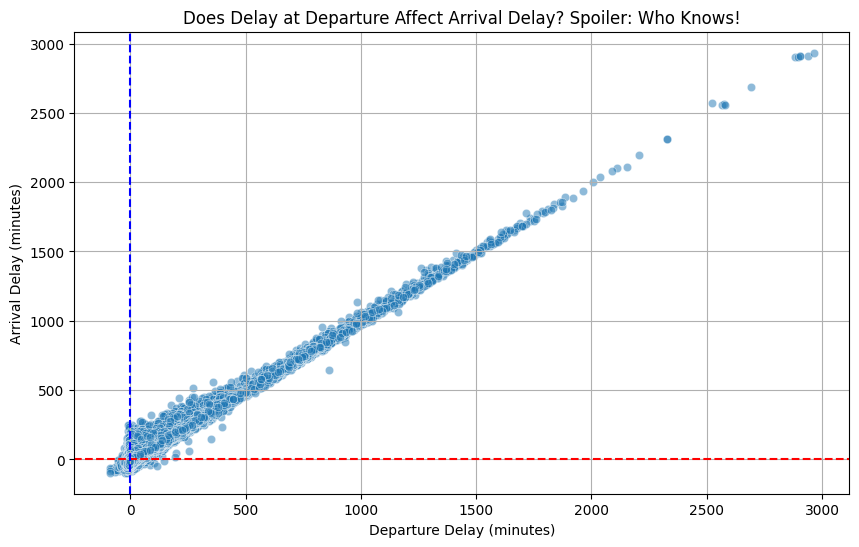

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf_merged, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="green", linestyle="--")  # Reference line for on-time departures

plt.grid(True)
plt.show()

In [4]:
# data seems to make sense at first sight.
# let's take a look at the when

<Axes: ylabel='Frequency'>

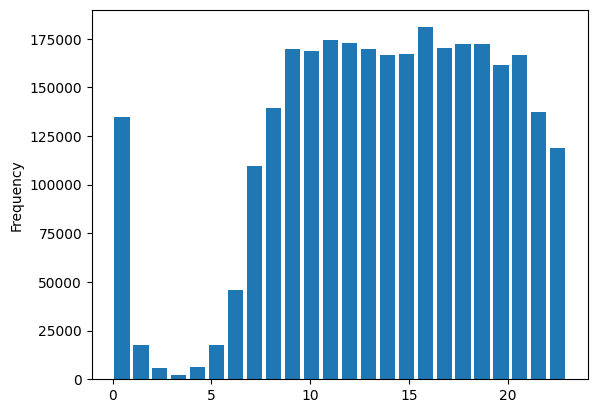

In [5]:
# Histogram of trips per hour of the day
fdf_merged["arr_datetime"].dt.hour.plot.hist(bins=24, rwidth=0.8)

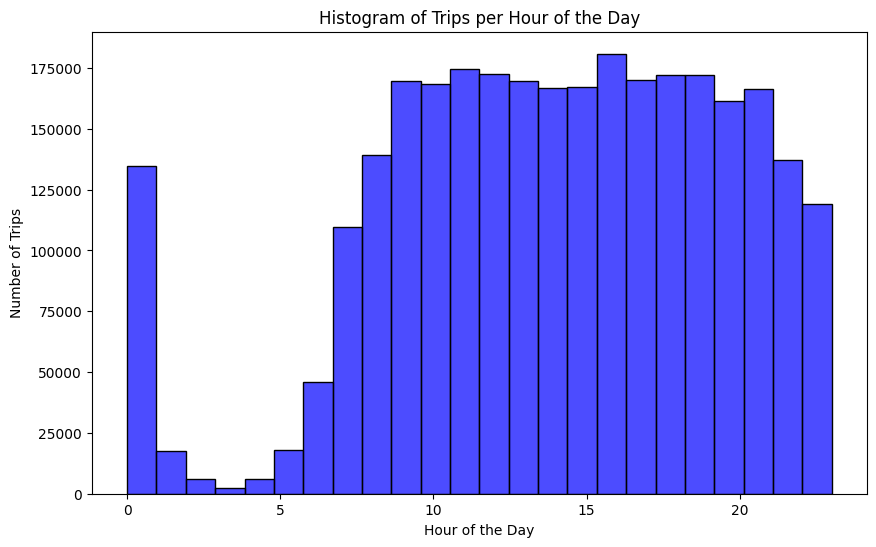

In [6]:
# another Histogram of trips per hour of the day
plt.figure(figsize=(10, 6))
sns.histplot(fdf_merged["arr_datetime"].dt.hour, bins=24, kde=False, color='blue', alpha=0.7)

# Add titles and labels
plt.title("Histogram of Trips per Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")

# Show the plot
plt.show()

<Axes: ylabel='Frequency'>

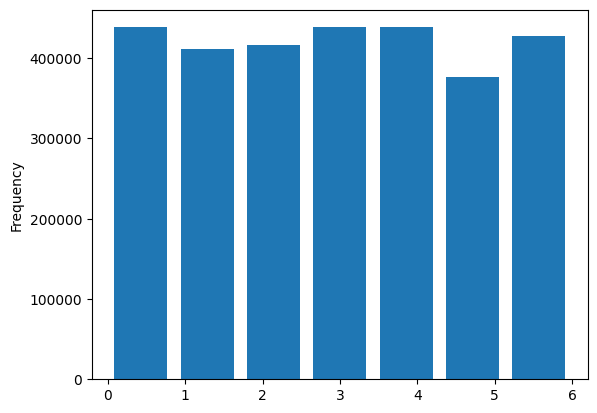

In [7]:
# Histogram of trips per day of the week
fdf_merged["arr_datetime"].dt.dayofweek.plot.hist(bins=7, rwidth=0.8)

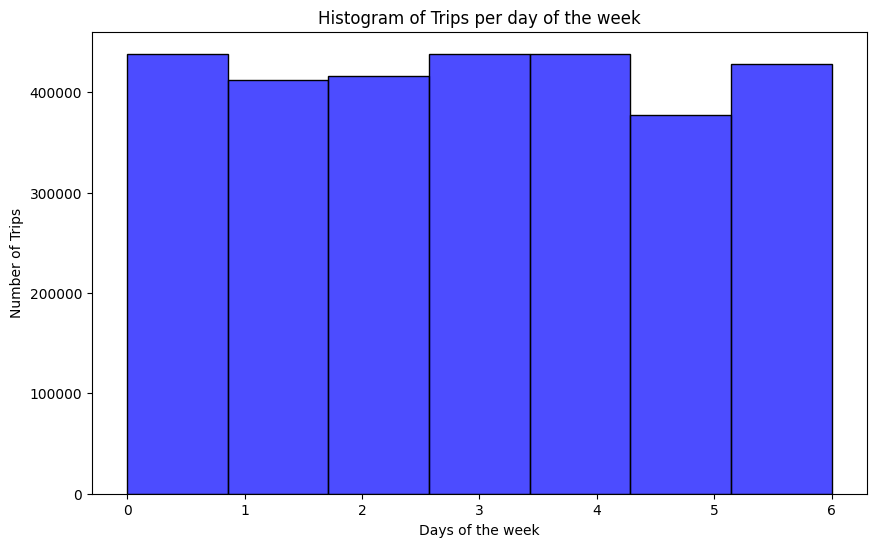

In [8]:
# another Histogram of trips per day of the week
plt.figure(figsize=(10, 6))
sns.histplot(fdf_merged["arr_datetime"].dt.dayofweek, bins=7, kde=False, color="blue", alpha=0.7)

# Add titles and labels
plt.title("Histogram of Trips per day of the week")
plt.xlabel("Days of the week")
plt.ylabel("Number of Trips")

# Show the plot
plt.show()

In [9]:
# distribution of flights per weekday sorted by year

In [10]:
# get flights in arbitrary intervalls
def getfldep(start, end):
    return fdf_merged.loc[ (fdf_merged["dep_datetime"] >= start) & (fdf_merged["dep_datetime"] < end)]

def getflarr(start, end):
    return  fdf_merged.loc[ (fdf_merged["arr_datetime"] >= start) & (fdf_merged["arr_datetime"] < end)]

In [11]:
# sorting some data per year
fl19 = getfldep("2019", "2020")
fl19 = fl19["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

fl20 = getfldep("2020", "2021")
fl20 = fl20["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

fl21 = getfldep("2021", "2022")
fl21 = fl21["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

fl22 = getfldep("2022", "2023")
fl22 = fl22["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

[(0.9, 8.0), (11.0, 16.0)]

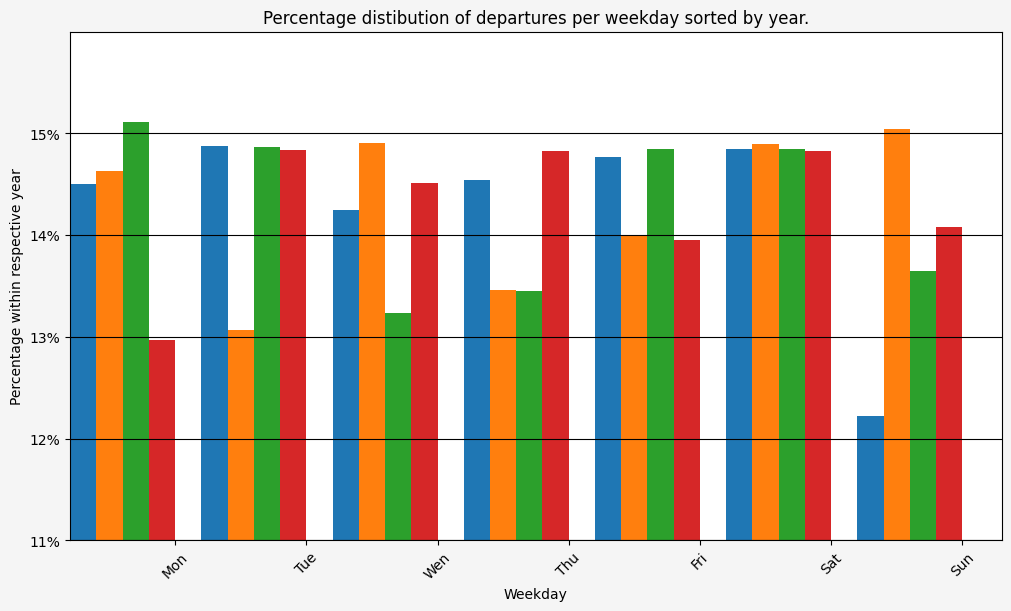

In [12]:
# plotting bar plot 
fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="whitesmoke",
    layout="constrained",
)

xtick_label=["Mon", "Tue", "Wen", "Thu", "Fri", "Sat", "Sun"]
ytick_label=[ str(x) + "%" for x in range(11, 16)]

ax.set_title("Percentage distibution of departures per weekday sorted by year.")
ax.set_xlabel("Weekday")
ax.set_ylabel("Percentage within respective year")
ax.set_xticks([x + 0.7 for x in range(1, 8)], xtick_label, rotation=45)
ax.set_yticks([y for y in range(11, 16)], ytick_label)

ax.bar([x for x in range(1, 8)], fl19, width=0.2)
ax.bar([x + 0.2 for x in range(1, 8)], fl20, width=0.2)
ax.bar([x + 0.40 for x in range(1, 8)], fl21, width=0.2)
ax.bar([x + 0.6 for x in range(1, 8)], fl22, width=0.2)
ax.grid(True, color = "black", axis = "y")
ax.set(xlim=(0.9, 8), ylim=(11, 16))

In [13]:
# taking a look at total flights per year
fdf_merged.groupby(fdf_merged["FL_DATE"].dt.to_period("Y")).size()

FL_DATE
2019    747135
2020    469856
2021    598740
2022    675632
2023    456724
Freq: Y-DEC, dtype: int64

In [14]:
# taking a look at total flights per month
fdf_merged.groupby(fdf_merged["FL_DATE"].dt.to_period("M")).size()

FL_DATE
2019-01    58720
2019-02    53838
2019-03    63969
2019-04    61141
2019-05    64037
2019-06    63767
2019-07    66205
2019-08    66559
2019-09    61282
2019-10    64069
2019-11    60761
2019-12    62787
2020-01    61294
2020-02    57587
2020-03    65132
2020-04    31415
2020-05    17974
2020-06    22482
2020-07    35211
2020-08    37717
2020-09    32183
2020-10    35217
2020-11    36532
2020-12    37112
2021-01    36196
2021-02    32883
2021-03    43912
2021-04    44665
2021-05    49385
2021-06    54148
2021-07    58231
2021-08    58276
2021-09    54142
2021-10    56313
2021-11    54932
2021-12    55657
2022-01    53942
2022-02    49665
2022-03    56536
2022-04    55581
2022-05    57982
2022-06    58038
2022-07    59568
2022-08    59147
2022-09    56203
2022-10    57671
2022-11    55244
2022-12    56055
2023-01    54539
2023-02    50284
2023-03    58066
2023-04    56414
2023-05    58635
2023-06    57797
2023-07    60306
2023-08    60683
Freq: M, dtype: int64

In [15]:
# having an overview of the when let's take a look at the where

In [16]:
# Create a GeoDataFrame from the merged data
geometry_origin = [Point(xy) for xy in zip(fdf_merged["LONGITUDE_ORIGIN"], fdf_merged["LATITUDE_ORIGIN"])]
geometry_dest = [Point(xy) for xy in zip(fdf_merged["LONGITUDE_DEST"], fdf_merged["LATITUDE_DEST"])]

# Create separate GeoDataFrames for origin and destination airports
gdf_origin = gpd.GeoDataFrame(fdf_merged, geometry=geometry_origin)
gdf_dest = gpd.GeoDataFrame(fdf_merged, geometry=geometry_dest)

In [17]:
# Load world data for the basemap
world_path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(world_path)

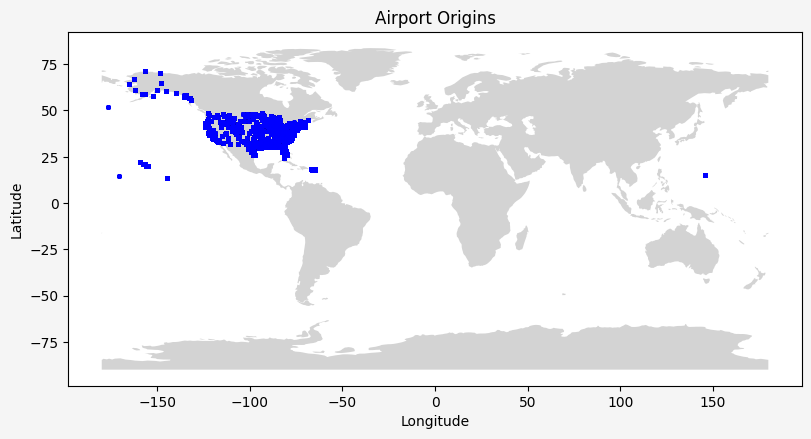

In [18]:
# Create the figure and axes with Matplotlib
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="whitesmoke", layout="constrained")

# Plot the world basemap on the axes
world.plot(ax=ax, color="lightgray")

# plotting gdf_origin  (GeoDataFrame for airport origins)
gdf_origin.plot(ax=ax, marker="o", color="blue", markersize=5)

# Add titles, labels, etc...
ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

In [19]:
# notice the outliar and focus on cluster

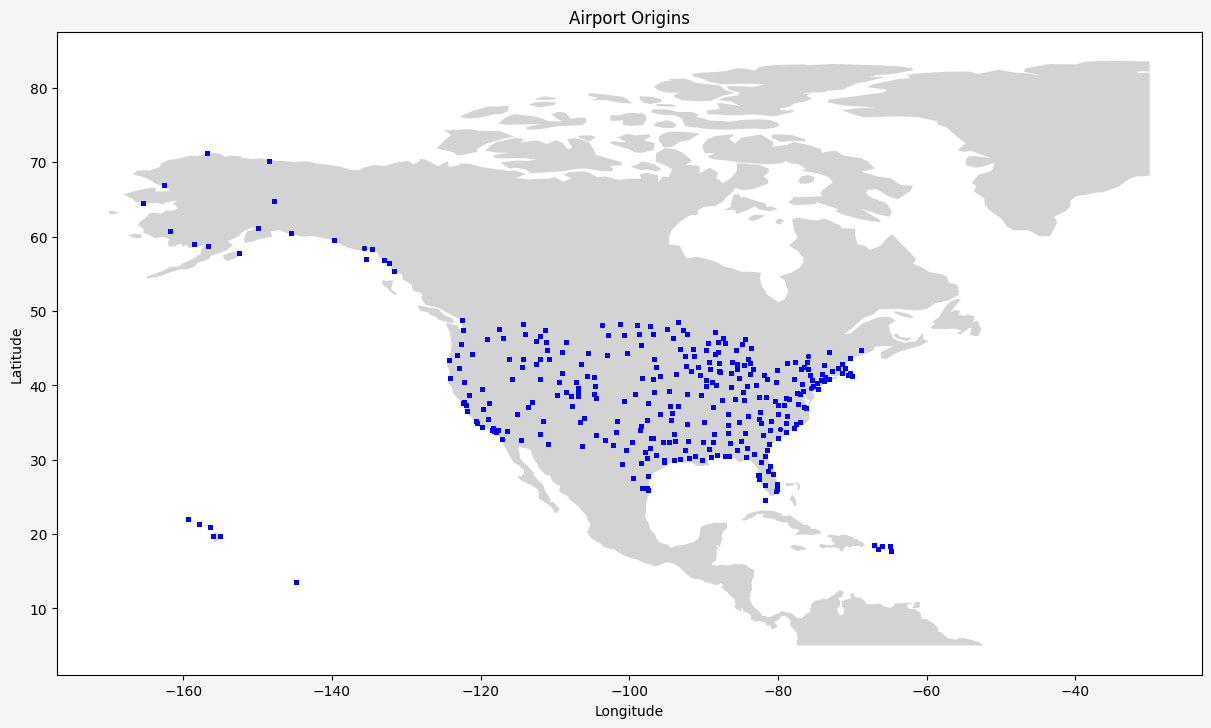

In [20]:
# Define bounding box for North America (roughly)
north_america_bbox = box(-170, 5, -30, 85)  # (min_lon, min_lat, max_lon, max_lat)

# Clip the world land data to the bounding box of North America
north_america = world.clip(north_america_bbox)

# define plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor="whitesmoke", layout="constrained")

# plotting northamerica
north_america.plot(ax=ax, color="lightgray")

# plotting gdf_origin on top of it  (GeoDataFrame for airport origins)
gdf_origin[
    (85 >= gdf_origin["LATITUDE_ORIGIN"]) & 
    (gdf_origin["LATITUDE_ORIGIN"] >= 5) & 
    (-30 >= gdf_origin["LONGITUDE_ORIGIN"]) &
    (gdf_origin["LONGITUDE_ORIGIN"] >= -170)
].plot(ax=ax, marker='o', color='blue', markersize=5)

ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.savefig("NA_Airports.png")
plt.show()

In [21]:
# notice Alaska, Hawaii?, Guantanamo and focus on cluster

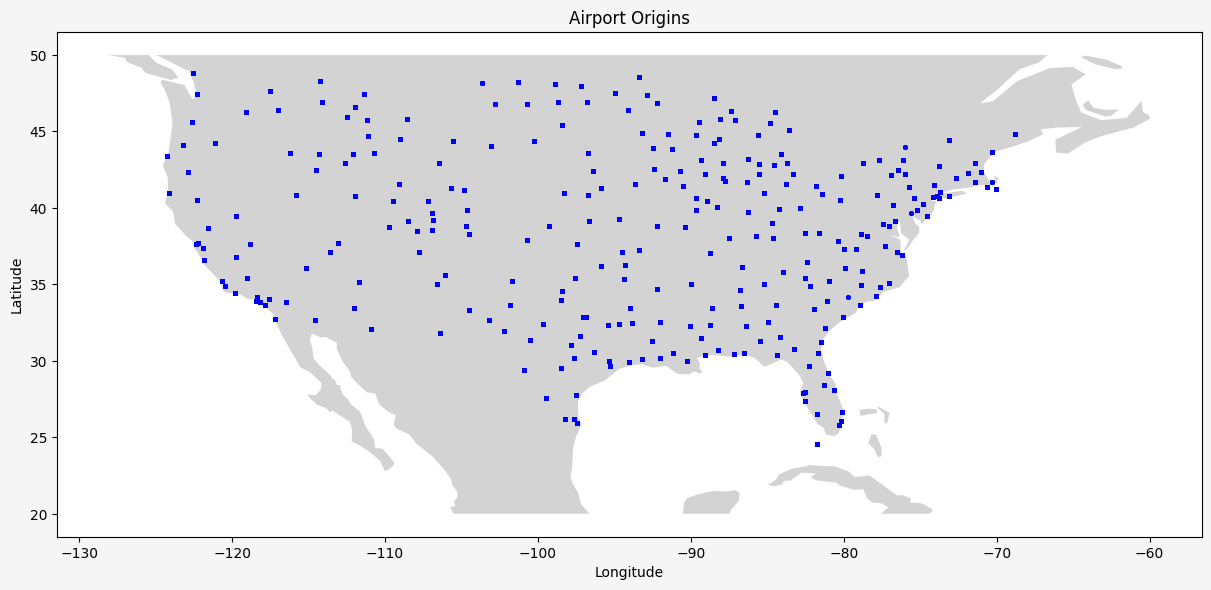

In [22]:
# USA (roughly)
north_america_bbox = box(-130, 20, -60, 50)  # (min_lon, min_lat, max_lon, max_lat)

# Clip the world land data to the bounding box of North America
north_america = world.clip(north_america_bbox)

# define plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor="whitesmoke", layout="constrained")

# plotting northamerica
north_america.plot(ax=ax, color="lightgray")

# plotting gdf_origin on top of it  (GeoDataFrame for airport origins)
gdf_origin[
    (50 >= gdf_origin["LATITUDE_ORIGIN"]) & 
    (gdf_origin["LATITUDE_ORIGIN"] >= 20) & 
    (-60 >= gdf_origin["LONGITUDE_ORIGIN"]) &
    (gdf_origin["LONGITUDE_ORIGIN"] >= -130)
].plot(ax=ax, marker='o', color='blue', markersize=5)

ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.savefig("NA_Airports.png")
plt.show()

In [23]:
# expecting mostly short-distance flights, since dataset contains mainly locations in USA

Text(0.5, 1.0, 'Boxplot of distances')

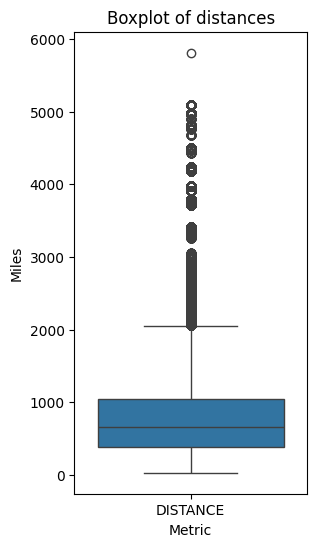

In [24]:
# setting up the boxplots

# prepairing data for boxplots to take a view about outliers when it comes to distances
melted_data = fdf_merged.melt(value_vars=["DISTANCE"], var_name="Metric", value_name="Miles")

# plotting
plt.figure(figsize=(3,6))
sns.boxplot(x="Metric", y="Miles", data=melted_data, legend=False)
plt.title("Boxplot of distances")

Text(0, 0.5, 'Distance')

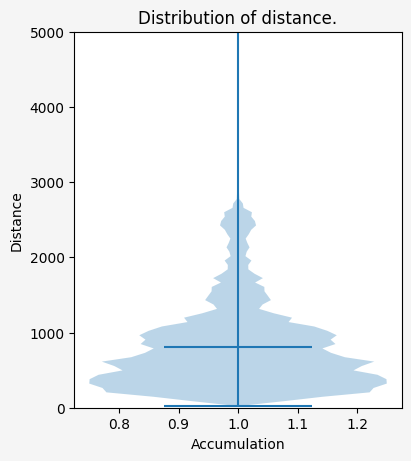

In [25]:
# violinplot of the same
fig, ax = plt.subplots(
    figsize=(4, 4.5),
    facecolor="whitesmoke",
    layout="constrained",
)

ax.violinplot(fdf_merged["DISTANCE"], showmeans=True)
ax.set(ylim=(0, 5000))

ax.set_title("Distribution of distance.")
ax.set_xlabel("Accumulation")
ax.set_ylabel("Distance")

In [26]:
# checking out unique locations and destinations
print(f"origin cities: {fdf_merged["ORIGIN_CITY"].nunique()}")
print(f"origins: {fdf_merged["IATA_ORIGIN"].nunique()}")
print()
print(f"destination cities: {fdf_merged["DEST_CITY"].nunique()}")
print(f"destinations: {fdf_merged["IATA_DEST"].nunique()}")

origin cities: 322
origins: 326

destination cities: 323
destinations: 327


In [27]:
# taking a look at how many airport-iatas have missing geo-locations
print(f"{len(missing_airports)} airports not accounted for.")
print()
print(sorted(missing_airports))

53 airports not accounted for.

['ALS', 'ALW', 'ATY', 'AZA', 'BFF', 'BFM', 'BIH', 'BKG', 'BLV', 'CDB', 'CGI', 'CKB', 'DDC', 'DEC', 'EAR', 'EAT', 'ECP', 'FOD', 'HGR', 'HHH', 'HVN', 'IAG', 'IPT', 'JST', 'LBE', 'LBF', 'LBL', 'LCK', 'MCW', 'OGD', 'OGS', 'OWB', 'PAE', 'PBG', 'PGD', 'PGV', 'PRC', 'PSM', 'PUW', 'PVU', 'RIW', 'SCK', 'SFB', 'SHR', 'SLN', 'STS', 'SWO', 'TBN', 'UIN', 'USA', 'VCT', 'XWA', 'YKM']


In [28]:
# let's take a look at cities and IATA
# expecting names corresponding to mostly cities in the USA 

In [29]:
# scoping out origin_cities with the highest count of flights
fdf_merged["ORIGIN_CITY"].value_counts().head(10)

ORIGIN_CITY
Chicago, IL              156023
Atlanta, GA              152253
Dallas/Fort Worth, TX    129446
Denver, CO               117390
New York, NY             112989
Charlotte, NC             93352
Houston, TX               86346
Los Angeles, CA           85304
Washington, DC            78286
Phoenix, AZ               74411
Name: count, dtype: int64

In [30]:
# scoping out origin_airports with the highest count of flights
fdf_merged["IATA_ORIGIN"].value_counts().head(10)

IATA_ORIGIN
ATL    152253
DFW    129446
ORD    121019
DEN    117390
CLT     93352
LAX     85304
PHX     74411
LAS     72993
SEA     70050
MCO     63712
Name: count, dtype: int64

In [31]:
# scoping out the top ten most popular routes (cities)
route_counts = fdf_merged.groupby(["ORIGIN_CITY", "DEST_CITY"]).size().reset_index(name="flight_count")
most_pop_routes = route_counts.sort_values(by="flight_count", ascending=False)
most_pop_routes.head(10)

/tmp/ipykernel_3155/190406296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  route_counts = fdf_merged.groupby(["ORIGIN_CITY", "DEST_CITY"]).size().reset_index(name="flight_count")


,ORIGIN_CITY,DEST_CITY,flight_count
89212,"New York, NY","Chicago, IL",6775
24484,"Chicago, IL","New York, NY",6572
89188,"New York, NY","Boston, MA",5618
15532,"Boston, MA","New York, NY",5591
113221,"San Francisco, CA","Los Angeles, CA",5358
75649,"Los Angeles, CA","San Francisco, CA",5212
7326,"Atlanta, GA","New York, NY",4882
89166,"New York, NY","Atlanta, GA",4872
63936,"Kahului, HI","Honolulu, HI",4656
75536,"Los Angeles, CA","Las Vegas, NV",4627


In [32]:
# scoping out the top ten most popular routes (IATA)
route_counts = fdf_merged.groupby(["IATA_ORIGIN", "IATA_DEST"]).size().reset_index(name="flight_count")
most_pop_routes = route_counts.sort_values(by="flight_count", ascending=False)
most_pop_routes.head(10)

/tmp/ipykernel_3155/4036424402.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  route_counts = fdf_merged.groupby(["IATA_ORIGIN", "IATA_DEST"]).size().reset_index(name="flight_count")


,IATA_ORIGIN,IATA_DEST,flight_count
92391,SFO,LAX,5358
58161,LAX,SFO,5212
59744,LGA,ORD,4735
73717,OGG,HNL,4656
75392,ORD,LGA,4634
58054,LAX,LAS,4627
46659,HNL,OGG,4554
57402,LAS,LAX,4550
58046,LAX,JFK,4403
54786,JFK,LAX,4305


In [33]:
# the when and where seems covered 

In [34]:
# filtering out only flights that are not cancelled
non_cancelled_flights = fdf_merged[~fdf_merged["CANCELLED"]]

Text(0.5, 1.0, 'Boxplot of air and elapsed time')

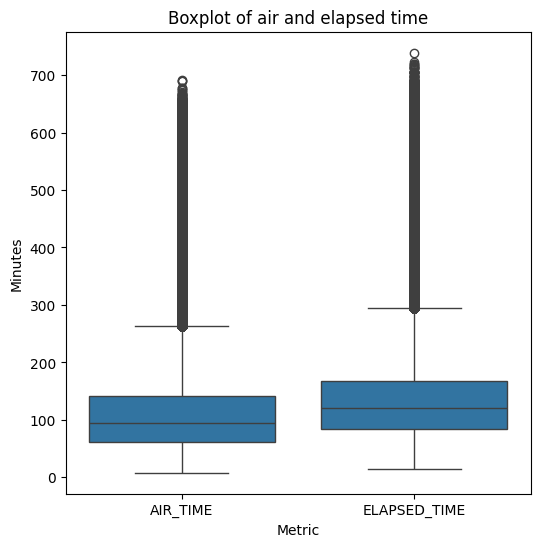

In [35]:
# prepairing data for boxplots to take a view about outliers when it comes to flightdurations
melted_data = non_cancelled_flights.melt(value_vars=["AIR_TIME", "ELAPSED_TIME"], 
                                         var_name="Metric", value_name="Minutes")

# setting up the boxplots
plt.figure(figsize=(6,6))
sns.boxplot(x="Metric", y="Minutes", data=melted_data, legend=False)
plt.title("Boxplot of air and elapsed time")

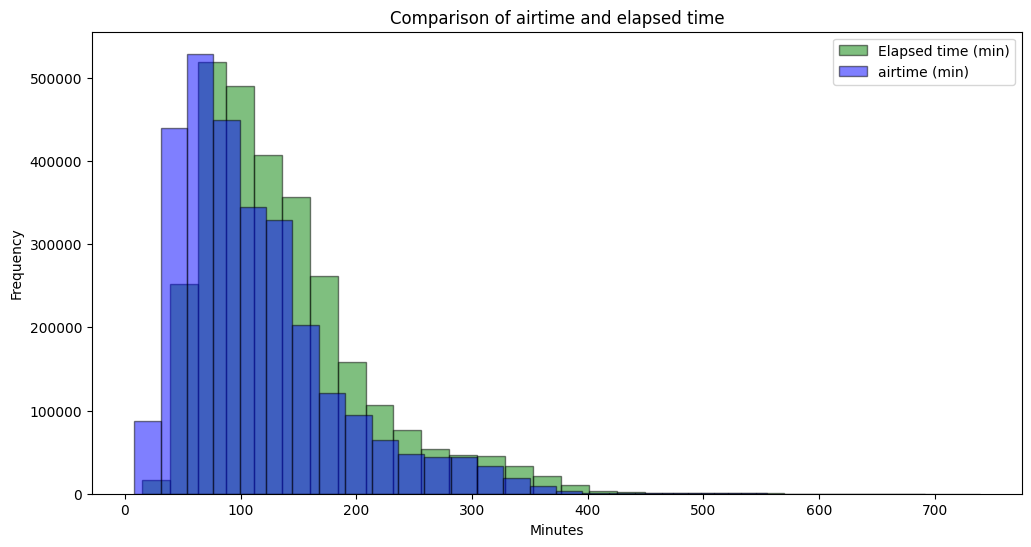

In [36]:
plt.figure(figsize=(12, 6))

plt.hist(non_cancelled_flights["ELAPSED_TIME"], bins=30, alpha=0.5, label="Elapsed time (min)", color="green", edgecolor="black")
plt.hist(non_cancelled_flights["AIR_TIME"], bins=30, alpha=0.5, label="airtime (min)", color="blue", edgecolor="black")

plt.title("Comparison of airtime and elapsed time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.legend()

In [37]:
# for the insignificant purpuses i have in mind data seems alright